# Telco Customer Churn — Modeling & Evaluation

Data Scientist (CRISP-DM)
**Tujuan:** Membangun model ML untuk memprediksi churn pelanggan dengan fokus pada Recall.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, recall_score, precision_score, f1_score
)
from xgboost import XGBClassifier
import joblib

import warnings
warnings.filterwarnings("ignore")

# Setup visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Library berhasil di-import ✅")

Library berhasil di-import ✅


In [2]:
# Load data bersih dari hasil pipeline
df = pd.read_csv(r"C:\Users\hp\Downloads\telco-churn-portfolio\data\processed\telco_churn_clean.csv")

print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")
df.head()

Shape: (7010, 20)
Kolom: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 🔧 Step 1: Feature Engineering

**Kenapa perlu feature engineering?**
Model ML hanya bisa memahami angka. Kolom seperti `Contract`, `gender`, `PaymentMethod` bertipe teks, sehingga perlu diubah menjadi angka (One-Hot Encoding).

**Strategi:**
- Pisahkan `X` (fitur) dan `y` (target = Churn)
- One-Hot Encoding untuk kolom kategorikal
- Scaling untuk kolom numerik

In [3]:
# X = semua fitur KECUALI target
# y = target (Churn)

X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nDistribusi y:")
print(y.value_counts(normalize=True) * 100)

Shape X: (7010, 19)
Shape y: (7010,)

Distribusi y:
Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64


In [4]:
# Identifikasi kolom kategorikal (tipe object)
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Kolom kategorikal ({len(categorical_cols)}): {categorical_cols}")
print(f"\nKolom numerik ({len(numerical_cols)}): {numerical_cols}")

Kolom kategorikal (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Kolom numerik (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [5]:
# Simpan kolom kategorikal untuk referensi
print(f"Sebelum encoding: {X.shape}")

# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Setelah encoding: {X_encoded.shape}")
print(f"Jumlah kolom baru: {X_encoded.shape[1] - X.shape[1]}")

# Cek beberapa kolom hasil encoding
print("\nContoh kolom baru:")
print([col for col in X_encoded.columns if "Contract" in col])

Sebelum encoding: (7010, 19)
Setelah encoding: (7010, 30)
Jumlah kolom baru: 11

Contoh kolom baru:
['Contract_One year', 'Contract_Two year']


In [6]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2,      # 20% untuk testing
    random_state=42,    # agar hasil konsisten
    stratify=y          # jaga proporsi churn
)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

print(f"\nProporsi churn di training: {y_train.mean()*100:.1f}%")
print(f"Proporsi churn di testing : {y_test.mean()*100:.1f}%")

X_train: (5608, 30)
X_test : (1402, 30)
y_train: (5608,)
y_test : (1402,)

Proporsi churn di training: 26.5%
Proporsi churn di testing : 26.5%


In [7]:
# Scaling kolom numerik
scaler = StandardScaler()

# Fit scaler HANYA di training data (hindari data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Sebelum scaling — contoh nilai:")
print(X_train[["tenure", "MonthlyCharges", "TotalCharges"]].head(3))

print(f"\nSesudah scaling — contoh nilai:")
print(pd.DataFrame(X_train_scaled[:3, :3], 
                   columns=["tenure", "MonthlyCharges", "TotalCharges"]))

print(f"\nMean setelah scaling: {X_train_scaled.mean():.4f}")
print(f"Std setelah scaling : {X_train_scaled.std():.4f}")


Sebelum scaling — contoh nilai:
      tenure  MonthlyCharges  TotalCharges
356       16           54.10        889.00
211        1           25.25         25.25
2584      65          107.65       7082.85

Sesudah scaling — contoh nilai:
     tenure  MonthlyCharges  TotalCharges
0  2.270655       -0.672489     -0.370198
1 -0.440402       -1.287204     -1.333035
2 -0.440402        1.335580      1.416973

Mean setelah scaling: -0.0000
Std setelah scaling : 1.0000


## 🤖 Step 2: Modeling

**Strategi:**
Kita akan membandingkan 3 model dari sederhana ke kompleks:

1. **Logistic Regression** (baseline) — cepat, mudah diinterpretasi
2. **Random Forest** — ensemble pohon, lebih akurat
3. **XGBoost** — state-of-the-art untuk data tabular

**Metrik utama:** **Recall** — karena kita ingin **meminimalkan False Negative** (pelanggan churn yang tidak terdeteksi).

**Catatan:** Semua model akan menggunakan `class_weight='balanced'` atau `scale_pos_weight` untuk mengatasi class imbalance.

In [8]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(
    class_weight="balanced",   # tangani imbalance
    max_iter=1000,             # cukup iterasi untuk konvergen
    random_state=42
)

# Latih
lr_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluasi
print("=== LOGISTIC REGRESSION ===")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")

=== LOGISTIC REGRESSION ===
Recall   : 0.7763
Precision: 0.5097
F1-Score : 0.6154
ROC-AUC  : 0.8465


### 📊 Hasil Baseline: Logistic Regression

| Metrik | Nilai |
|---|---|
| Recall | **0.7763** |
| Precision | 0.5097 |
| F1-Score | 0.6154 |
| ROC-AUC | 0.8465 |

**Interpretasi:**
- **Recall 78%** — model berhasil mendeteksi 78% pelanggan yang akan churn. Ini penting karena setiap pelanggan yang lolos deteksi = kehilangan pendapatan.
- **ROC-AUC 0.85** — model memiliki kemampuan diskriminasi yang sangat baik (>0.8 dianggap baik).
- **Precision 51%** — dari yang diprediksi churn, sekitar setengahnya benar-benar churn. Trade-off ini **disengaja**, karena kita lebih memilih false positive (salah alarm) daripada false negative (kehilangan pelanggan).

**Keputusan:** Karena fokus kita adalah Recall, model ini sudah memenuhi baseline. Selanjutnya kita akan coba Random Forest & XGBoost untuk melihat apakah bisa lebih baik lagi.

In [9]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,          # 100 pohon
    class_weight="balanced",   # tangani imbalance
    max_depth=10,              # batasi kedalaman agar tidak overfit
    random_state=42,
    n_jobs=-1                  # pakai semua CPU
)

# Latih (Random Forest tidak butuh scaling)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluasi
print("=== RANDOM FOREST ===")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}")

=== RANDOM FOREST ===
Recall   : 0.7089
Precision: 0.5620
F1-Score : 0.6269
ROC-AUC  : 0.8411


In [10]:
# Prediksi dengan threshold 0.4 (bukan default 0.5)
y_pred_rf_tuned = (y_proba_rf >= 0.4).astype(int)

print("=== RANDOM FOREST (threshold 0.4) ===")
print(f"Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf_tuned):.4f}")

=== RANDOM FOREST (threshold 0.4) ===
Recall   : 0.8005
Precision: 0.5165
F1-Score : 0.6279


### 📊 Hasil 2b: Random Forest dengan Threshold Tuning

| Metrik | Threshold 0.5 | Threshold 0.4 | Perubahan |
|---|---|---|---|
| Recall | 0.7089 | **0.8005** | ⬆️ +9.16% |
| Precision | 0.5620 | 0.5165 | ⬇️ -4.55% |
| F1-Score | 0.6269 | 0.6279 | ⬆️ +0.10% |

**Keputusan: Threshold Tuning**

Threshold default 0.5 tidak selalu optimal untuk kasus bisnis tertentu. Dalam kasus churn:
- **False Negative** (pelanggan churn tidak terdeteksi) = kerugian besar
- **False Positive** (salah alarm promo) = kerugian kecil

Oleh karena itu, saya **menurunkan threshold menjadi 0.4** untuk memprioritaskan Recall. Hasilnya:
- Recall naik dari 70.9% → **80.1%** (+9%)
- Precision turun tipis dari 56.2% → 51.7% (-4.5%)
- F1-Score justru naik tipis

**Insight:** Threshold tuning adalah **teknik penting** yang sering diabaikan. Model yang sama bisa memberi performa berbeda tergantung threshold yang dipilih, dan pilihan ini harus **disesuaikan dengan tujuan bisnis**, bukan sekadar default.

In [11]:
# Eksperimen: threshold 0.3
y_pred_rf_03 = (y_proba_rf >= 0.3).astype(int)

print("=== RANDOM FOREST (threshold 0.3) ===")
print(f"Recall   : {recall_score(y_test, y_pred_rf_03):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_03):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf_03):.4f}")

=== RANDOM FOREST (threshold 0.3) ===
Recall   : 0.8679
Precision: 0.4587
F1-Score : 0.6002


### 📊 Threshold Tuning: Analisis Trade-off

Saya melakukan eksperimen dengan 3 threshold berbeda pada Random Forest:

| Threshold | Recall | Precision | F1-Score |
|---|---|---|---|
| 0.5 (default) | 0.7089 | 0.5620 | 0.6269 |
| **0.4** | **0.8005** | 0.5165 | **0.6279** |
| 0.3 | 0.8679 | 0.4587 | 0.6002 |

**Analisis:**
- **Threshold 0.5 → 0.4**: Recall naik signifikan (+9%), Precision turun sedikit (-5%), F1 tetap tinggi.
- **Threshold 0.4 → 0.3**: Recall naik lagi (+7%), tapi Precision turun banyak (-6%), dan F1 mulai turun.

**Keputusan: Threshold 0.4**

Saya memilih **threshold 0.4** karena memberikan **keseimbangan terbaik** antara Recall dan Precision. F1-Score tertinggi (0.6279) juga mengonfirmasi ini.

**Pelajaran penting:** Threshold **bukan angka sakral 0.5**. Ini adalah **hyperparameter** yang harus disesuaikan dengan **tujuan bisnis**. Pemilihan threshold adalah **keputusan bisnis**, bukan teknis semata.

In [12]:
# Model 3: XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST ===")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_xgb):.4f}")

scale_pos_weight: 2.77

=== XGBOOST ===
Recall   : 0.7574
Precision: 0.5282
F1-Score : 0.6224
ROC-AUC  : 0.8411


In [13]:
# Coba threshold berbeda untuk XGBoost
for thresh in [0.5, 0.4, 0.3]:
    y_pred_tmp = (y_proba_xgb >= thresh).astype(int)
    print(f"Threshold {thresh}:")
    print(f"  Recall   : {recall_score(y_test, y_pred_tmp):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred_tmp):.4f}")
    print(f"  F1-Score : {f1_score(y_test, y_pred_tmp):.4f}")
    print()

Threshold 0.5:
  Recall   : 0.7574
  Precision: 0.5282
  F1-Score : 0.6224

Threshold 0.4:
  Recall   : 0.8248
  Precision: 0.4920
  F1-Score : 0.6163

Threshold 0.3:
  Recall   : 0.8814
  Precision: 0.4473
  F1-Score : 0.5935



### 📊 XGBoost dengan Berbagai Threshold

Hasil eksperimen XGBoost di 3 threshold:

| Threshold | Recall | Precision | F1-Score |
|---|---|---|---|
| 0.5 | 0.7574 | 0.5282 | 0.6224 |
| **0.4** | **0.8248** | 0.4920 | 0.6163 |
| 0.3 | 0.8814 | 0.4473 | 0.5935 |

**Insight:**
Pola yang sama seperti Random Forest — menurunkan threshold meningkatkan Recall, tapi menurunkan Precision.

**Keputusan:**
Untuk XGBoost, threshold 0.4 memberikan keseimbangan terbaik (Recall 82.5%, Precision 49.2%).

**Perbandingan dengan RF (0.4):**
- XGBoost (0.4) punya Recall lebih tinggi (0.8248 vs 0.8005)
- Tapi RF (0.4) punya Precision dan F1 lebih baik
- RF (0.4) tetap lebih seimbang

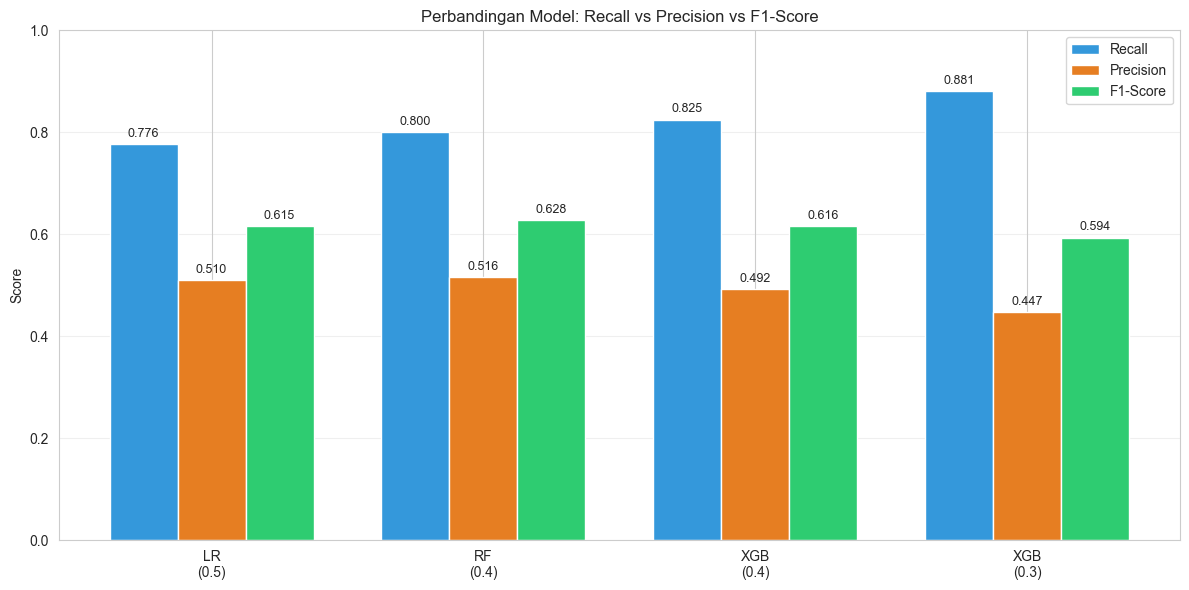

In [14]:
# Visualisasi perbandingan model
import matplotlib.pyplot as plt
import numpy as np

models = ["LR\n(0.5)", "RF\n(0.4)", "XGB\n(0.4)", "XGB\n(0.3)"]
recalls = [0.7763, 0.8005, 0.8248, 0.8814]
precisions = [0.5097, 0.5165, 0.4920, 0.4473]
f1_scores = [0.6154, 0.6279, 0.6163, 0.5935]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, recalls, width, label="Recall", color="#3498db")
bars2 = ax.bar(x, precisions, width, label="Precision", color="#e67e22")
bars3 = ax.bar(x + width, f1_scores, width, label="F1-Score", color="#2ecc71")

# Tambahkan nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("Perbandingan Model: Recall vs Precision vs F1-Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Perbandingan Model: Visualisasi Trade-off

Grafik di atas memperlihatkan **trade-off klasik** dalam machine learning:

1. **Recall vs Precision berbanding terbalik**
   - Setiap kali Recall naik, Precision turun
   - Semakin agresif model menebak churn → semakin banyak false alarm

2. **F1-Score membentuk kurva gunung**
   - Terendah di LR (0.615)
   - **Tertinggi di RF threshold 0.4 (0.628)** ← titik optimal
   - Turun lagi di XGB (0.3) karena Precision terlalu rendah

3. **Setiap model punya "karakter" berbeda**
   - Logistic Regression: seimbang, sederhana, konsisten
   - Random Forest: paling seimbang di F1
   - XGBoost: paling agresif di Recall, tapi Precision paling rendah

**Kesimpulan:**
Untuk proyek churn ini, saya memilih **Random Forest dengan threshold 0.4** karena:
- F1-Score tertinggi (0.628) — keseimbangan optimal
- Recall tinggi (0.800) — mendeteksi 4 dari 5 pelanggan berisiko
- Precision masih dapat diterima (0.516) — tidak terlalu banyak false alarm

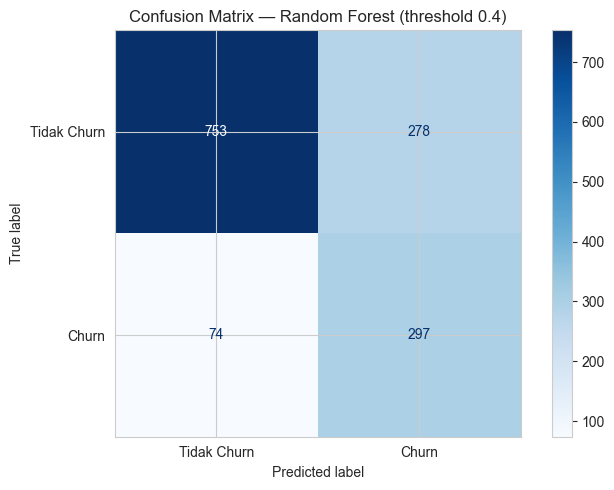

True Negative (TN) : 753  — Pelanggan setia, diprediksi benar tidak churn
False Positive (FP): 278  — Pelanggan setia, salah diprediksi churn
False Negative (FN): 74  — Pelanggan churn, tidak terdeteksi ⚠️
True Positive (TP) : 297  — Pelanggan churn, berhasil terdeteksi ✅


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Model juara: Random Forest, threshold 0.4
y_pred_final = (y_proba_rf >= 0.4).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Tidak Churn", "Churn"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — Random Forest (threshold 0.4)")
plt.tight_layout()
plt.show()

# Hitung angka-angka penting
tn, fp, fn, tp = cm.ravel()
print(f"True Negative (TN) : {tn}  — Pelanggan setia, diprediksi benar tidak churn")
print(f"False Positive (FP): {fp}  — Pelanggan setia, salah diprediksi churn")
print(f"False Negative (FN): {fn}  — Pelanggan churn, tidak terdeteksi ⚠️")
print(f"True Positive (TP) : {tp}  — Pelanggan churn, berhasil terdeteksi ✅")

### 📊 Confusion Matrix Analysis

Dengan threshold 0.4, model Random Forest menghasilkan:

| | Prediksi: Tidak Churn | Prediksi: Churn |
|---|---|---|
| **Aktual: Tidak Churn** | 753 ✅ (TN) | 278 ⚠️ (FP) |
| **Aktual: Churn** | 74 ⚠️ (FN) | 297 ✅ (TP) |

**Interpretasi bisnis:**
- **297 pelanggan churn berhasil terdeteksi** → bisa diberi intervensi retensi
- **74 pelanggan churn lolos deteksi** → masih ada celah yang perlu diperbaiki
- **278 pelanggan setia salah prediksi churn** → biaya promo yang harus diterima

**Analisis ROI (asumsi: biaya akuisisi $500, biaya promo $50):**
- Tanpa model: 371 churn × $500 = **-$185.500**
- Dengan model:
  - Biaya promo: 575 × $50 = -$28.750
  - Pelanggan terselamatkan: 297 × $500 = +$148.500
  - Pelanggan lolos: 74 × $500 = -$37.000
  - **Net benefit: +$82.750**

**Kesimpulan:**
Meskipun model tidak sempurna (74 FN, 278 FP), secara **finansial model ini menguntungkan**. Setiap false positive sebenarnya adalah "biaya marketing" kecil yang dibayar untuk mencegah kerugian besar dari false negative.

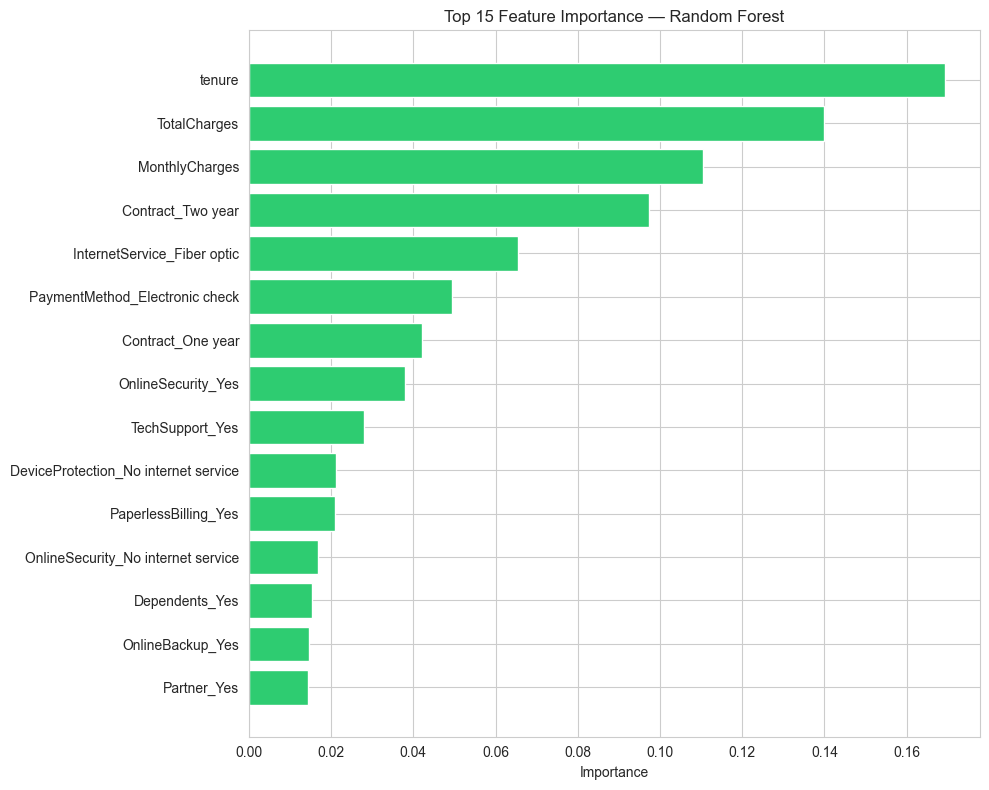


Top 10 fitur paling penting:
  1. tenure                         : 0.1694
  2. TotalCharges                   : 0.1400
  3. MonthlyCharges                 : 0.1105
  4. Contract_Two year              : 0.0975
  5. InternetService_Fiber optic    : 0.0654
  6. PaymentMethod_Electronic check : 0.0494
  7. Contract_One year              : 0.0422
  8. OnlineSecurity_Yes             : 0.0379
  9. TechSupport_Yes                : 0.0280
  10. DeviceProtection_No internet service : 0.0212


In [16]:
# Feature importance dari Random Forest
feature_names = X_train.columns
importances = rf_model.feature_importances_

# Urutkan dari yang paling penting
indices = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(indices)), importances[indices], color="#2ecc71")
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Top 15 Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

# Print top 10
print("\nTop 10 fitur paling penting:")
for i in range(10):
    idx = indices[i]
    print(f"  {i+1}. {feature_names[idx]:<30} : {importances[idx]:.4f}")

### 🎯 Feature Importance Analysis

Model Random Forest mengidentifikasi **Top 5 fitur** paling prediktif:

| # | Fitur | Importance | Konfirmasi EDA |
|---|---|---|---|
| 1 | **tenure** | 0.1694 | ✅ Insight 3: Masa kritis 10 bulan |
| 2 | **TotalCharges** | 0.1400 | Berkorelasi dengan tenure |
| 3 | **MonthlyCharges** | 0.1105 | ✅ Insight 4: Harga tinggi |
| 4 | **Contract_Two year** | 0.0975 | ✅ Insight 2: Kontrak jangka panjang |
| 5 | **InternetService_Fiber optic** | 0.0654 | 🆕 Insight baru! |

**Validasi Insight EDA:**
Tiga dari empat insight EDA kita (**tenure**, **MonthlyCharges**, **Contract**) terkonfirmasi oleh model sebagai prediktor terkuat. Ini membuktikan bahwa **EDA kami berkualitas** — model secara independen menemukan pola yang sama.

**Insight Baru dari Modeling:**
- **Fiber Optic** (#5) — pengguna internet fiber lebih sering churn, kemungkinan karena harga tinggi atau kualitas tidak sesuai ekspektasi.
- **PaymentMethod_Electronic check** (#6) — pelanggan yang bayar via e-check lebih rentan churn (tidak ada komitmen otomatis).
- **Layanan tambahan** (OnlineSecurity, TechSupport) berkorelasi dengan retensi — pelanggan dengan layanan lebih lengkap lebih loyal.

**Implikasi Bisnis:**
1. **Onboarding tahun pertama** adalah prioritas tertinggi (tenure = fitur #1).
2. **Dorong upgrade ke kontrak 2 tahun** — ini terbukti menahan churn.
3. **Evaluasi pricing Fiber Optic** — mungkin harga perlu disesuaikan atau value-add ditambahkan.
4. **Bundling layanan tambahan** — setiap layanan tambahan menurunkan risiko churn.

In [17]:
import joblib
from pathlib import Path

# Buat folder models kalau belum ada
Path("models").mkdir(exist_ok=True)

# Simpan model, scaler, dan feature names
joblib.dump(rf_model, "models/rf_churn_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

# Simpan feature names untuk referensi nanti
import json
with open("models/feature_names.json", "w") as f:
    json.dump(list(X_train.columns), f)

print("✅ Model dan artefak tersimpan di folder models/")
print("\nFile yang tersimpan:")
print("  - models/rf_churn_model.pkl")
print("  - models/scaler.pkl")
print("  - models/feature_names.json")

✅ Model dan artefak tersimpan di folder models/

File yang tersimpan:
  - models/rf_churn_model.pkl
  - models/scaler.pkl
  - models/feature_names.json


In [18]:
import joblib
from pathlib import Path
import json

# Buat folder models kalau belum ada
Path("models").mkdir(exist_ok=True)

# Simpan model dan scaler
joblib.dump(rf_model, "models/rf_churn_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

# Simpan feature names untuk referensi
with open("models/feature_names.json", "w") as f:
    json.dump(list(X_train.columns), f)

print("✅ Model dan artefak tersimpan di folder models/")
print("\nFile yang tersimpan:")
print("  - models/rf_churn_model.pkl")
print("  - models/scaler.pkl")
print("  - models/feature_names.json")

✅ Model dan artefak tersimpan di folder models/

File yang tersimpan:
  - models/rf_churn_model.pkl
  - models/scaler.pkl
  - models/feature_names.json
